# Financial Market News & Data Assistant

A multi-tool LangGraph chatbot that answers questions about stocks, market
performance, and financial news, and backs its answers with real numbers and
charts rather than free-text guesses.

This builds on the classroom tool-calling tutorial (arxiv, Wikipedia, Tavily
search, wired through `ToolNode` and `tools_condition`) and pushes it a step
further in three ways:

1. **Real financial data tools**, not just search. A live stock quote, a
   market index overview, a price history chart, and a currency converter,
   each built as its own tool with real numeric output, alongside Tavily for
   news.
2. **A loop instead of a dead end.** In the classroom version, once a tool
   runs, the graph goes straight to `END` and the user just sees raw tool
   output. Here, tool results loop back to the model, so it actually reads
   the numbers and writes a proper answer.
3. **Multi-tool chaining in one question.** A single question like "give me
   Nvidia's price, a chart, and the latest news" causes the model to call
   three different tools in sequence and then combine everything into one
   answer, which is demonstrated directly below.

Run the cells top to bottom. You will need `GROQ_API_KEY` and
`TAVILY_API_KEY` in a `.env` file.

## Configuration

Everything the notebook depends on lives in this one cell: SSL handling,
environment variables, and a User-Agent patch that Wikipedia's API now
requires. Keeping this in one place means restarting the kernel only ever
requires re-running this cell before anything else.

In [1]:
import truststore
truststore.inject_into_ssl()

import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY", "")
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY", "")

import wikipedia
import requests as _requests

if not getattr(_requests.get, "_is_patched", False):
    _original_get = _requests.get

    def _patched_get(*args, **kwargs):
        headers = kwargs.get("headers", {})
        headers["User-Agent"] = "FinancialAssistant/1.0 (educational project)"
        kwargs["headers"] = headers
        return _original_get(*args, **kwargs)

    _patched_get._is_patched = True
    _requests.get = _patched_get

print("Groq key loaded:", bool(os.environ.get("GROQ_API_KEY")))
print("Tavily key loaded:", bool(os.environ.get("TAVILY_API_KEY")))

Groq key loaded: True
Tavily key loaded: True


## How this is structured

Before building anything, it helps to see the shape of the final graph, since
every tool added below exists to feed data into this loop.

```
START -> tool_calling_llm -> (tool call requested?) -> tools -> back to tool_calling_llm
                                     |
                                     no tool call needed
                                     v
                                    END
```

The model is asked a question. If it decides it needs data it cannot know on
its own (today's AAPL price, for instance), it emits a tool call instead of a
final answer. The graph runs that tool, feeds the result back to the model as
a new message, and asks the model again. This repeats, possibly through
several different tools, until the model has enough information to answer in
plain text with no further tool calls, at which point the graph ends. This is
the standard ReAct-style pattern, and it's the piece the classroom version
was missing, since it stopped after exactly one tool call.

## General-purpose tools

These three come from the classroom tutorial. `ArxivAPIWrapper` needed a
small patch, since `langchain_community` 0.4.2's built-in call still uses an
older version of the `arxiv` package's API that no longer exists in current
versions.

In [2]:
from langchain_community.utilities import ArxivAPIWrapper
from langchain_community.tools import ArxivQueryRun
import arxiv as arxiv_pkg


def _fixed_arxiv_run(self, query: str) -> str:
    try:
        results = arxiv_pkg.Client().results(
            self.arxiv_search(query[: self.ARXIV_MAX_QUERY_LENGTH], max_results=self.top_k_results)
        )
        docs = [
            f"Published: {r.updated.date()}\nTitle: {r.title}\nAuthors: {', '.join(a.name for a in r.authors)}\nSummary: {r.summary}"
            for r in results
        ]
        return "\n\n".join(docs)[: self.doc_content_chars_max] if docs else "No good Arxiv Result was found"
    except Exception as e:
        return f"Arxiv exception: {e}"


ArxivAPIWrapper.run = _fixed_arxiv_run

api_wrapper_arxiv = ArxivAPIWrapper(top_k_results=2, doc_content_chars_max=500)
arxiv = ArxivQueryRun(api_wrapper=api_wrapper_arxiv)
arxiv.invoke("Attention is all you need")

C:\Users\agavali\AppData\Local\Temp\ipykernel_39748\1647746973.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.utilities import ArxivAPIWrapper


'Published: 2021-05-06\nTitle: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet\nAuthors: Luke Melas-Kyriazi\nSummary: The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the extent to which attention is responsible for this strong performance remains unclear. In this short report, we ask: is the attention layer even necessary? Specifi'

In [3]:
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

api_wrapper_wiki = WikipediaAPIWrapper(top_k_results=1, doc_content_chars_max=500)
wiki = WikipediaQueryRun(api_wrapper=api_wrapper_wiki)
wiki.invoke("What is Machine Learning?")

'Page: Machine learning\nSummary: Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from  data and generalize to unseen data, and thus perform tasks without being explicitly programmed. Advances in the field of deep learning have allowed neural networks, a class of statistical algorithms, to surpass many previous machine learning approaches in performance.\nStatistics and mathematical optimisation m'

In [4]:
from langchain_community.tools.tavily_search import TavilySearchResults

tavily = TavilySearchResults(max_results=4)
tavily.invoke("latest financial market news today")

C:\Users\agavali\AppData\Local\Temp\ipykernel_39748\2039125729.py:3: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily = TavilySearchResults(max_results=4)


[{'title': 'MarketWatch: Stock Market News - Financial News ...',
  'url': 'https://www.marketwatch.com',
  'content': '9 hours ago\n\n  \n\n### Sports betting to build wealth is becoming the new American dream\n\n9 hours ago\n\n  \n\n### Social Security union says it needs $3 billion and another 20,000 workers to fix long wait times and ‘ghost offices’\n\n15 hours ago\n\n  \n\n## Economy\n\nSee All\n\nImage 14\n\n### The U.S. government plans to crack down on its $40 trillion debt — but brace for a ‘wrenching time’ ahead\n\n18 hours ago\n\nImage 15\n\n### The rise in interest rates hit a ‘raw nerve’ at the White House. Bessent’s plan has analysts on edge.\n\nAug 20\n\nTMUBMUSD10Y 0.64%\n\n### You’ve all heard AI is remaking the economy. Here’s how it’s changing lives — for better or worse.\n\nAug 20\n\n  \n\n### The national debt just hit $40 trillion. Here’s how it can hurt Americans.\n\nAug 19 [...] 12 hours ago\n\n### American consumers are delivering a retail reality check as they

## Financial data tools

This is the actual step up from the tutorial. Search tools are good at
finding articles, but they are not reliable for a live number like a stock
price, since that number changes by the minute and a search result could be
hours or days old. These four tools go straight to a live data source
instead, using `yfinance` (free, no API key) for prices and
`frankfurter.app` (free, no API key) for exchange rates.

Each one is written with the `@tool` decorator, and the docstring on each
function is not just documentation, it is what the model reads to decide
which tool fits a given question, so the wording matters.

In [5]:
from langchain_core.tools import tool
import yfinance as yf


@tool
def get_stock_quote(ticker: str) -> str:
    '''Get the current price, daily change, volume, and market cap for a stock
    ticker symbol, for example AAPL, MSFT, or TSLA. Use this whenever the user
    asks for a specific stock's current price, quote, or how a stock is doing
    today.'''
    try:
        stock = yf.Ticker(ticker.upper())
        info = stock.fast_info

        price = info.last_price
        prev_close = info.previous_close
        change = price - prev_close
        pct_change = (change / prev_close) * 100 if prev_close else 0.0

        return (
            f"{ticker.upper()} quote:\n"
            f"Price: ${price:,.2f}\n"
            f"Change: {change:+.2f} ({pct_change:+.2f}%)\n"
            f"Day range: ${info.day_low:,.2f} - ${info.day_high:,.2f}\n"
            f"52 week range: ${info.year_low:,.2f} - ${info.year_high:,.2f}\n"
            f"Volume: {info.last_volume:,.0f}"
        )
    except Exception as e:
        return f"Could not retrieve a quote for '{ticker}': {e}"


get_stock_quote.invoke({"ticker": "AAPL"})

'AAPL quote:\nPrice: $311.64\nChange: +1.95 (+0.63%)\nDay range: $309.97 - $313.33\n52 week range: $224.69 - $344.57\nVolume: 12,152,491'

In [6]:
@tool
def get_market_overview() -> str:
    '''Get the current level and daily percentage change for major stock market
    indices: S&P 500, Nasdaq, Dow Jones, and FTSE 100. Use this when the user
    asks a general question about how the market or markets are doing today,
    rather than about one specific stock.'''
    indices = {"S&P 500": "^GSPC", "Nasdaq": "^IXIC", "Dow Jones": "^DJI", "FTSE 100": "^FTSE"}
    lines = []
    for name, symbol in indices.items():
        try:
            info = yf.Ticker(symbol).fast_info
            change_pct = ((info.last_price - info.previous_close) / info.previous_close) * 100
            lines.append(f"{name}: {info.last_price:,.2f} ({change_pct:+.2f}%)")
        except Exception as e:
            lines.append(f"{name}: unavailable ({e})")
    return "Market overview:\n" + "\n".join(lines)


get_market_overview.invoke({})

'Market overview:\nS&P 500: 7,665.05 (-0.12%)\nNasdaq: 26,074.90 (-0.40%)\nDow Jones: 53,473.28 (+0.36%)\nFTSE 100: 10,854.32 (+0.42%)'

In [7]:
import matplotlib.pyplot as plt
import os

os.makedirs("charts", exist_ok=True)


@tool
def plot_stock_chart(ticker: str, period: str = "3mo") -> str:
    '''Generate a price history chart for a stock ticker over a given period and
    save it to disk. Valid periods include 1mo, 3mo, 6mo, 1y, and 5y. Use this
    when the user asks to see a chart, graph, or price trend for a stock, not
    just its current price.'''
    try:
        history = yf.Ticker(ticker.upper()).history(period=period)
        if history.empty:
            return f"No price history found for '{ticker}'."

        start_price = history["Close"].iloc[0]
        end_price = history["Close"].iloc[-1]
        pct_change = ((end_price - start_price) / start_price) * 100
        high = history["Close"].max()
        low = history["Close"].min()

        fig, ax = plt.subplots(figsize=(9, 4.5))
        ax.plot(history.index, history["Close"], linewidth=1.8)
        ax.set_title(f"{ticker.upper()} price, last {period}")
        ax.set_ylabel("Close price (USD)")
        ax.grid(alpha=0.25)
        fig.tight_layout()

        path = f"charts/{ticker.upper()}_{period}.png"
        fig.savefig(path, dpi=130)
        plt.close(fig)

        return (
            f"Chart saved to {path}. Over the last {period}, {ticker.upper()} moved from "
            f"${start_price:,.2f} to ${end_price:,.2f} ({pct_change:+.2f}%), "
            f"with a high of ${high:,.2f} and a low of ${low:,.2f}."
        )
    except Exception as e:
        return f"Could not generate a chart for '{ticker}': {e}"


plot_stock_chart.invoke({"ticker": "AAPL", "period": "3mo"})

'Chart saved to charts/AAPL_3mo.png. Over the last 3mo, AAPL moved from $308.06 to $311.64 (+1.16%), with a high of $339.79 and a low of $274.91.'

In [8]:
@tool
def convert_currency(amount: float, from_currency: str, to_currency: str) -> str:
    '''Convert an amount of money from one currency to another using current
    exchange rates. Currencies should be given as three letter codes, for
    example USD, EUR, GBP. Use this when the user asks about currency
    conversion or exchange rates.'''
    try:
        url = "https://api.frankfurter.app/latest"
        params = {"amount": amount, "from": from_currency.upper(), "to": to_currency.upper()}
        response = _requests.get(url, params=params, timeout=10)
        data = response.json()
        converted = data["rates"][to_currency.upper()]
        rate = converted / amount
        return (
            f"{amount:,.2f} {from_currency.upper()} = {converted:,.2f} {to_currency.upper()} "
            f"(rate: 1 {from_currency.upper()} = {rate:.4f} {to_currency.upper()})"
        )
    except Exception as e:
        return f"Could not convert {from_currency} to {to_currency}: {e}"


convert_currency.invoke({"amount": 100, "from_currency": "USD", "to_currency": "EUR"})

'100.00 USD = 85.73 EUR (rate: 1 USD = 0.8573 EUR)'

## Assembling the model and the tool list

Seven tools in total: three general-purpose (arxiv, Wikipedia, Tavily) and
four financial (quote, market overview, chart, currency). The system prompt
matters as much as the tools themselves here, since it is what pushes the
model toward using real numbers and clear formatting instead of a vague
paragraph.

In [9]:
tools = [arxiv, wiki, tavily, get_stock_quote, get_market_overview, plot_stock_chart, convert_currency]

from langchain_groq import ChatGroq

llm = ChatGroq(model="openai/gpt-oss-120b", temperature=0.2)
llm_with_tools = llm.bind_tools(tools)

SYSTEM_PROMPT = (
    "You are a financial market assistant. You have access to tools for live "
    "stock quotes, market index levels, price history charts, currency "
    "conversion, general web and news search, Wikipedia, and academic papers. "
    "Always use a tool to get a real number or a real headline rather than "
    "estimating one from memory, since prices and news change constantly. "
    "When you answer, use markdown formatting: short headers, bullet points "
    "for lists of figures or news items, and bold the key numbers. If you "
    "used a chart tool, mention what the chart shows rather than describing "
    "it as an image, since the chart itself is shown separately. "
    "This is general information, not personalized financial advice."
)

print(f"{len(tools)} tools bound to the model.")

7 tools bound to the model.


## State and graph

The state schema is the same as the tutorial's. The graph structure is where
the real change is: `tools` now points back to `tool_calling_llm` instead of
straight to `END`, which is what turns this from "run one tool and stop"
into an actual reasoning loop.

In [10]:
from typing_extensions import TypedDict
from typing import Annotated
from langchain_core.messages import AnyMessage, SystemMessage
from langgraph.graph.message import add_messages


class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]


def tool_calling_llm(state: State) -> dict:
    messages_with_system = [SystemMessage(content=SYSTEM_PROMPT)] + state["messages"]
    return {"messages": [llm_with_tools.invoke(messages_with_system)]}

In [11]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

builder = StateGraph(State)

builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition,
)
builder.add_edge("tools", "tool_calling_llm")

financial_bot = builder.compile()
print("Graph compiled.")

Graph compiled.


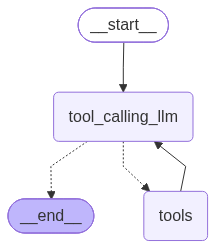

In [12]:
from IPython.display import Image, display

try:
    display(Image(financial_bot.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Could not render the diagram (this needs internet access to mermaid.ink):", e)

## Running it

The helper below sends one question, prints each step of the conversation so
the tool-calling loop is visible, renders the final answer as formatted
markdown rather than plain text, and automatically displays any chart image
that `plot_stock_chart` saved along the way.

In [13]:
import re
from IPython.display import Markdown


def run_financial_chatbot(query: str, show_steps: bool = True):
    print("=" * 78)
    print(f"Question: {query}")
    print("-" * 78)

    result = financial_bot.invoke({"messages": [{"role": "user", "content": query}]})
    messages = result["messages"]

    chart_paths = []
    for m in messages:
        if show_steps and m.type == "ai" and getattr(m, "tool_calls", None):
            calls = ", ".join(f"{c['name']}({c['args']})" for c in m.tool_calls)
            print(f"[model requests tool call] {calls}")
        if show_steps and m.type == "tool":
            preview = m.content[:120].replace("\n", " ")
            print(f"[tool result: {m.name}] {preview}...")
        if m.type == "tool" and m.name == "plot_stock_chart":
            found = re.search(r"charts/[\w\.]+\.png", m.content)
            if found:
                chart_paths.append(found.group())

    print("-" * 78)
    display(Markdown(messages[-1].content))

    for path in chart_paths:
        display(Image(filename=path))

    return result

### Example 1: a single live quote

This should trigger exactly one tool call, `get_stock_quote`, and the model
should report the actual price it received.

In [14]:
_ = run_financial_chatbot("What is Apple's stock price doing today?")

Question: What is Apple's stock price doing today?
------------------------------------------------------------------------------
[model requests tool call] get_stock_quote({'ticker': 'AAPL'})
[tool result: get_stock_quote] AAPL quote: Price: $311.66 Change: +1.97 (+0.64%) Day range: $309.97 - $313.33 52 week range: $224.69 - $344.57 Volume: ...
------------------------------------------------------------------------------


### Apple Inc. (AAPL) – Today’s Trading Summary  

- **Current price:** **$311.66**  
- **Change:** **+1.97** points (**+0.64%**)  
- **Day range:** $309.97 – $313.33  
- **52‑week range:** $224.69 – $344.57  
- **Volume:** 12,156,673 shares  

*This reflects the latest market data and is provided for informational purposes only.*

### Example 2: general market conditions

A broader question like this should route to `get_market_overview` rather
than a single-stock tool, since no ticker was mentioned.

In [15]:
_ = run_financial_chatbot("How are the markets doing today overall?")

Question: How are the markets doing today overall?
------------------------------------------------------------------------------
[model requests tool call] get_market_overview({'': {}})
[tool result: get_market_overview] Market overview: S&P 500: 7,666.41 (-0.10%) Nasdaq: 26,078.36 (-0.39%) Dow Jones: 53,487.15 (+0.39%) FTSE 100: 10,854.32...
------------------------------------------------------------------------------


## Market Overview (as of today)

- **S&P 500:** **7,666.41** (‑0.10%)
- **Nasdaq Composite:** **26,078.36** (‑0.39%)
- **Dow Jones Industrial Average:** **53,487.15** (+0.39%)
- **FTSE 100 (London):** **10,854.32** (+0.42%)

*The major U.S. indices are slightly lower, with the Nasdaq showing the biggest dip, while the Dow and FTSE 100 are modestly higher.*

### Example 3: a chart request

This exercises `plot_stock_chart`. Watch for the image appearing after the
model's written answer, pulled automatically from the tool's file path.

Question: Show me a 6 month price chart for Tesla
------------------------------------------------------------------------------
[model requests tool call] plot_stock_chart({'period': '6mo', 'ticker': 'TSLA'})
[tool result: plot_stock_chart] Chart saved to charts/TSLA_6mo.png. Over the last 6mo, TSLA moved from $409.38 to $355.94 (-13.05%), with a high of $445...
------------------------------------------------------------------------------


## Tesla (TSLA) – 6‑Month Price Chart  

- **Start price (6 months ago):** **$409.38**  
- **Current price:** **$355.94**  
- **Change:** **‑13.05 %** over the period  
- **High during period:** **$445.27**  
- **Low during period:** **$298.32**  

**Chart:** The plotted chart (saved as `charts/TSLA_6mo.png`) shows Tesla’s share price declining from the early‑April level near $410, peaking around $445 in late May, then trending lower with a dip to the $298 low in early July before stabilising near the current $356 level.  

*All figures are based on the latest market data.*

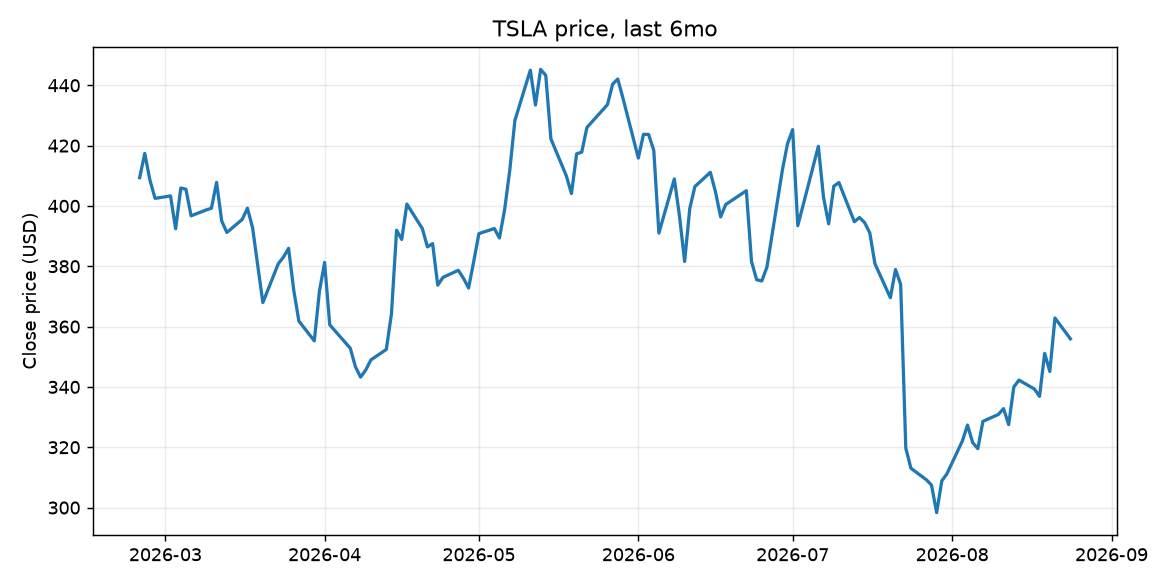

In [16]:
_ = run_financial_chatbot("Show me a 6 month price chart for Tesla")

### Example 4: currency conversion

A completely different tool, with no relation to stocks at all, showing the
model picks the right tool out of seven based purely on the question.

In [17]:
_ = run_financial_chatbot("If I convert 500 GBP to USD, how much is that?")

Question: If I convert 500 GBP to USD, how much is that?
------------------------------------------------------------------------------
[model requests tool call] convert_currency({'amount': 500, 'from_currency': 'GBP', 'to_currency': 'USD'})
[tool result: convert_currency] 500.00 GBP = 681.71 USD (rate: 1 GBP = 1.3634 USD)...
------------------------------------------------------------------------------


### Currency Conversion

- **£500 GBP** = **$681.71 USD**  
  *(Exchange rate: 1 GBP = 1.3634 USD)*

### Example 5: news via Tavily

This is the kind of question that needs a real web search rather than a
data API, since it is about current events and commentary rather than a
number.

In [18]:
_ = run_financial_chatbot("What is the latest news on the Federal Reserve's interest rate decisions?")

Question: What is the latest news on the Federal Reserve's interest rate decisions?
------------------------------------------------------------------------------
[model requests tool call] tavily_search_results_json({'query': 'latest news Federal Reserve interest rate decision 2024'})
[tool result: tavily_search_results_json] [{"title": "The Fed - Monetary Policy and Economic Developments", "url": "https://www.federalreserve.gov/publications/20...
[model requests tool call] tavily_search_results_json({'query': 'Federal Reserve interest rate decision November 2024 December 2024 latest news 2024 Fed cuts'})
[tool result: tavily_search_results_json] [{"title": "Fed meeting December 2024: Fed cuts rate by a quarter point", "url": "https://www.cnbc.com/2024/12/18/fed-ra...
------------------------------------------------------------------------------


**Latest Federal Reserve Interest‑Rate News (as of December 2024)**  

- **December 18, 2024 – FOMC decision**  
  - The Fed **cut the federal‑funds target range by 25 bps** to **4.25 % – 4.50 %**.  
  - This is the **third consecutive quarter‑point cut** (September, November, December) and a **total reduction of 100 bps** since the September meeting.  
  - The statement emphasized “greater confidence that inflation is moving sustainably toward 2 %” while noting a “solid pace of economic activity.”  
  - The Fed’s “dot‑plot” now projects **only two more cuts in 2025** and a neutral rate of about **3 %** in the longer run.  
  - *Source: CNBC – “Fed meeting December 2024: Fed cuts rate by a quarter point”*【0†content】  

- **November 7, 2024 – FOMC decision**  
  - The Committee **lowered the target range by 25 bps** to **4.50 % – 4.75 %**.  
  - The vote was unanimous; Governor Michelle Bowman joined the majority for the first time since 2005.  
  - Markets expected the move; the Fed signaled a “steady‑as‑she‑goes” path with another cut likely in December.  
  - The September “dot‑plot” still showed a **terminal rate near 2.9 %**, implying further cuts in 2025‑26.  
  - *Source: CNBC – “Fed rate decision November 2024”*【1†content】  

- **September 18, 2024 – FOMC decision**  
  - A **large 50‑bps cut** brought the range down to **4.75 % – 5.00 %** – the biggest single‑meeting move since 2022.  
  - The Fed cited “greater confidence” in inflation progress and a need to “recalibrate the policy stance.”  
  - This cut started the 2024 easing cycle that has now totaled **100 bps** of reductions.  
  - *Source: Federal Reserve “Monetary Policy and Economic Developments” summary*【0†content】  

- **Market reaction & outlook**  
  - **Treasury yields have risen** despite the cuts; the 2‑year yield is around **4.3 %**, slightly above the current policy range.  
  - **Mortgage rates have edged higher** (30‑year at ~6.8 %).  
  - CME FedWatch shows an **≈ 88 % probability** of another 25‑bps cut at the upcoming December meeting, which would push the range to **3.5 % – 3.75 %**.  
  - Analysts (e.g., Evercore ISI) expect the Fed to pause after the December cut to assess the impact on growth and inflation.  

**Key Take‑aways**  

- The Fed’s policy stance has shifted from **tightening to gradual easing**, with **three cuts in the last quarter of 2024**.  
- The **current target range is 4.25 % – 4.50 %** (as of Dec 18, 2024).  
- **Future cuts are likely limited**: two more in 2025 per the dot‑plot, with a neutral rate projected near **3 %**.  

*All figures are drawn from the latest official statements and reputable news outlets; they reflect the situation at the time of writing (late December 2024).*

### Example 6: multiple tools in a single question

This is the clearest demonstration of the loop-based architecture. A single
question here should cause the model to call three different tools in
sequence, quote, chart, and news, before writing one combined answer that
references all three.

Question: Give me Nvidia's current stock price, a 3 month price chart, and the latest news about Nvidia
------------------------------------------------------------------------------
[model requests tool call] get_stock_quote({'ticker': 'NVDA'})
[tool result: get_stock_quote] NVDA quote: Price: $210.38 Change: -5.00 (-2.32%) Day range: $208.62 - $215.59 52 week range: $164.07 - $236.54 Volume: ...
[model requests tool call] plot_stock_chart({'period': '3mo', 'ticker': 'NVDA'})
[tool result: plot_stock_chart] Chart saved to charts/NVDA_3mo.png. Over the last 3mo, NVDA moved from $214.61 to $210.38 (-1.97%), with a high of $225....
[model requests tool call] tavily_search_results_json({'query': 'latest news Nvidia'})
[tool result: tavily_search_results_json] [{"title": "Nvidia: Latest news and insights", "url": "https://www.networkworld.com/article/3562856/nvidia-latest-news-a...
------------------------------------------------------------------------------


## Nvidia (NVDA) – Quick Snapshot  

- **Current price:** **$210.38**  
- **Day change:** –$5.00 (**‑2.32%**)  
- **52‑week range:** $164.07 – $236.54  
- **Volume:** 56,857,316 shares  

---

## 3‑Month Price Chart  

The chart (saved as `charts/NVDA_3mo.png`) shows:

- **Start (3 months ago):** $214.61  
- **Current:** $210.38 (**‑1.97%** from three months earlier)  
- **High over period:** $225.30  
- **Low over period:** $190.01  

The trend is relatively flat with a slight downward drift, reflecting recent market volatility and mixed earnings guidance.

---

## Latest Nvidia News (as of August 2026)

- **Aug 20, 2026 – “Bring the Fire: Play Games on GeForce NOW With New Firefox Browser Support”** – Nvidia adds Firefox compatibility to its cloud‑gaming service, expanding platform reach.  
- **Aug 17, 2026 – “Securing the Infrastructure of Intelligence”** – A blog post outlining Nvidia’s new security framework for AI data centers and edge deployments.  
- **Aug 17, 2026 – “NVIDIA Guarantees SB Energy’s PORTS‑Pike Technology Campus in Ohio to Exclusively Host NVIDIA AI Compute”** – Partnership to host dedicated AI compute resources at a new Ohio campus.  
- **Aug 14, 2026 – “Universitas Gadjah Mada, Indosat and NVIDIA Open Indonesia’s First University AI Center”** – Collaboration to develop local AI talent and research in Indonesia.  
- **Aug 13, 2026 – “Class Is in Session: GeForce NOW Levels Up Linux, Chromebooks and More”** – Expanded support for Linux and ChromeOS devices on Nvidia’s streaming platform.  
- **May 21, 2026 – Yahoo Finance interview with CFO Colette Kress** – Discussion of FY 2027 outlook and chip‑revenue expectations.  
- **Mar 20, 2026 – Wall Street Journal: “NVIDIA’s CEO Projects $1 Trillion in AI Chip Sales as New Computing Era Begins”** – Jensen Huang forecasts a trillion‑dollar AI‑chip market within the next few years.  

*These headlines are drawn from Nvidia’s official newsroom and recent media coverage, representing the most current public information.*

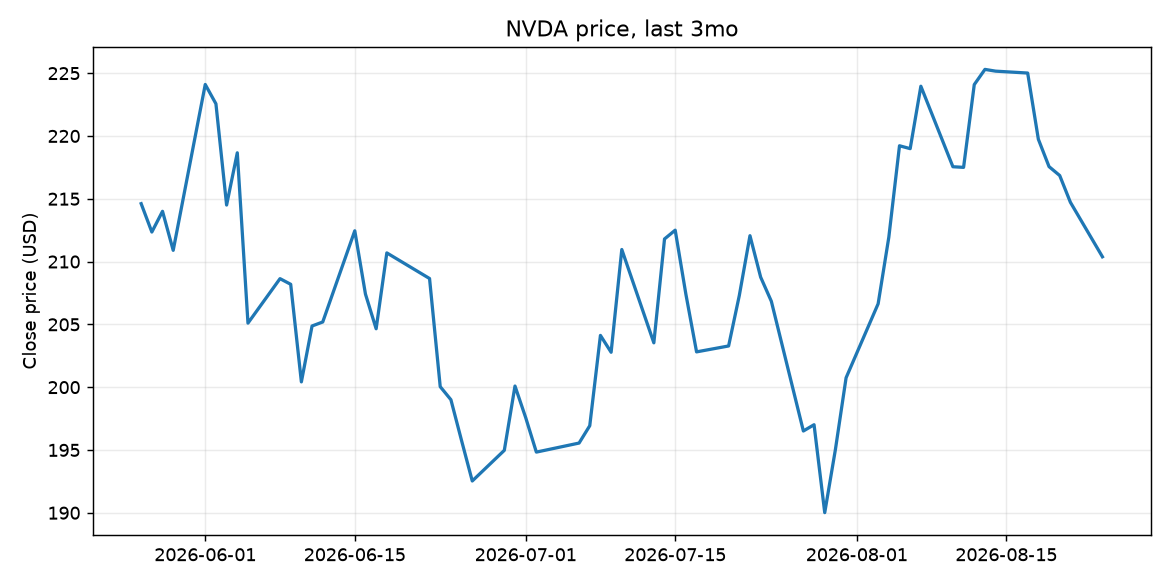

In [19]:
_ = run_financial_chatbot(
    "Give me Nvidia's current stock price, a 3 month price chart, and the latest news about Nvidia"
)